In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("superstore_clean.csv")

print(df.head())
print(df.info())
print(df.describe())

          Category         City        Country Customer.ID     Customer.Name  \
0  Office Supplies  Los Angeles  United States   LS-172304  Lycoris Saunders   
1  Office Supplies  Los Angeles  United States   MV-174854     Mark Van Huff   
2  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
3  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
4  Office Supplies  Los Angeles  United States   AP-109154    Arthur Prichep   

   Discount Market  \
0       0.0     US   
1       0.0     US   
2       0.0     US   
3       0.0     US   
4       0.0     US   

   ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ¨ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ®ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ¥ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ½ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ

In [3]:
print(df.isnull().sum())

Category                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            0
City                                                                                                                                                                                                                                                                                                                                                                                                                              

In [4]:
print("Total Sales:", df['Sales'].sum())

Total Sales: 12642905


In [5]:
print("Total Profit:", df['Profit'].sum())

Total Profit: 1467457.2912800002


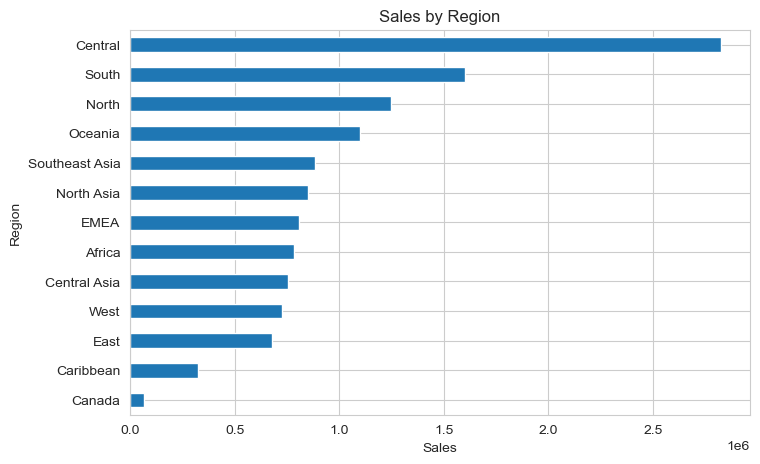

In [6]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

region_sales.plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Sales by Region')
plt.xlabel('Sales')
plt.show()

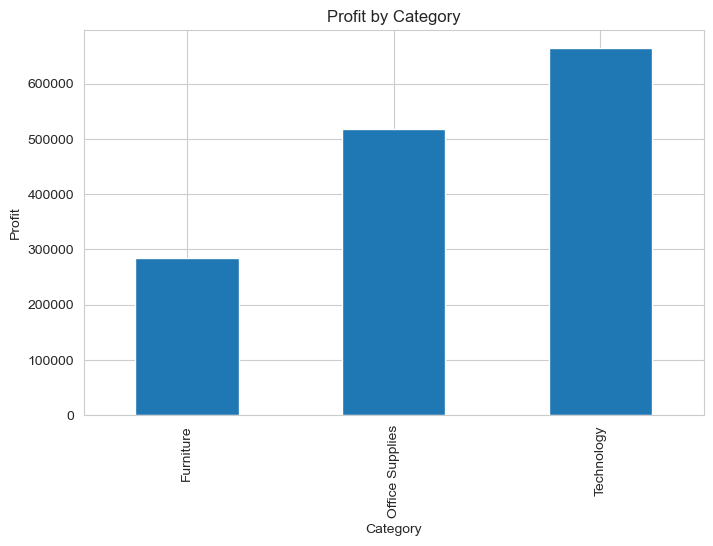

In [7]:
category_profit = df.groupby('Category')['Profit'].sum()

category_profit.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Profit by Category')
plt.ylabel('Profit')
plt.show()

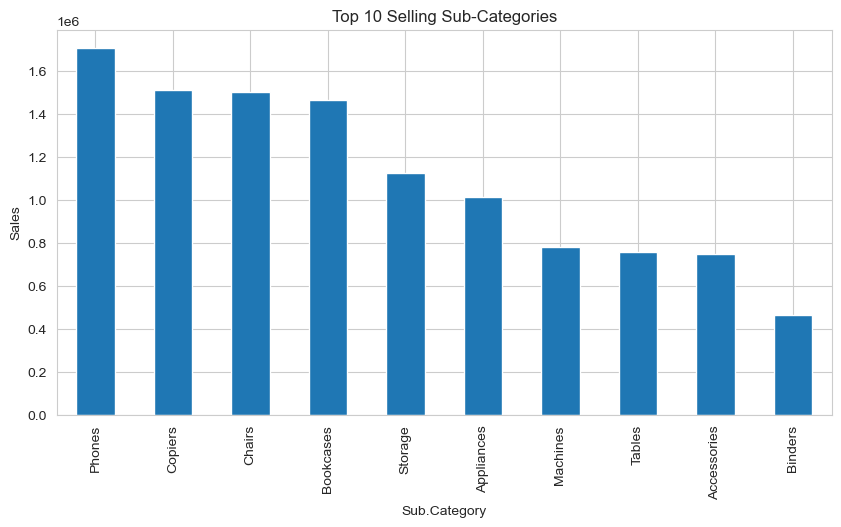

In [10]:
top_products = (
    df.groupby('Sub.Category')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Selling Sub-Categories')
plt.ylabel('Sales')
plt.show()

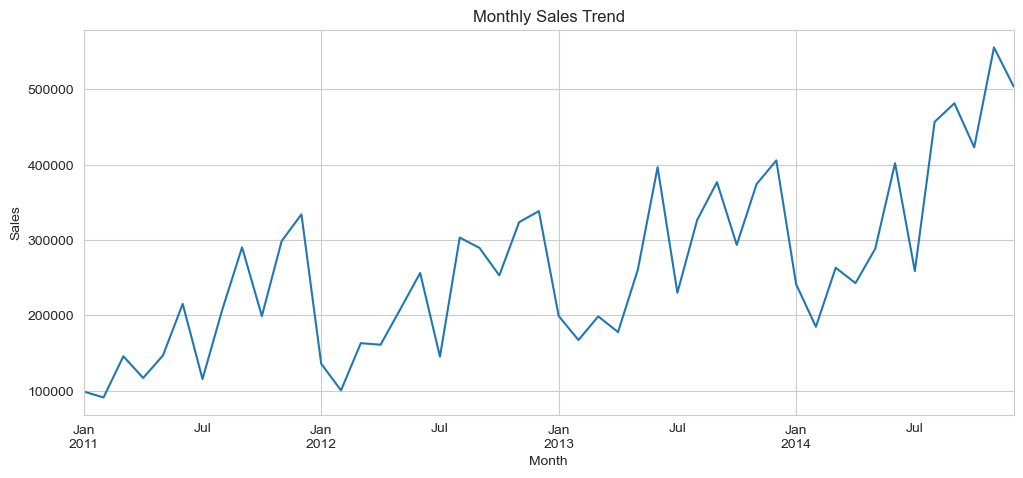

In [12]:
df['Order.Date'] = pd.to_datetime(df['Order.Date'])

monthly_sales = df.groupby(
    df['Order.Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.plot(
    figsize=(12,5)
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

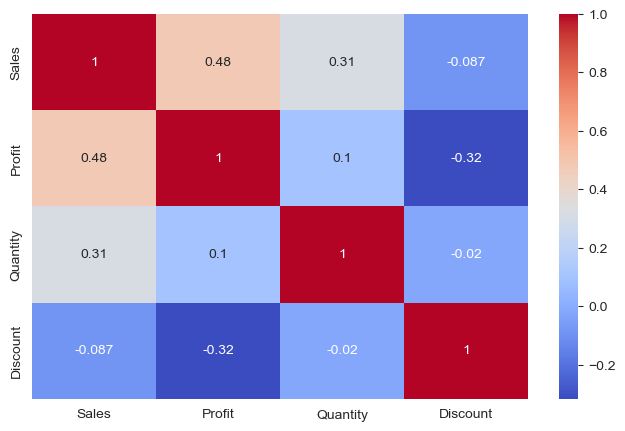

In [13]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Sales','Profit','Quantity','Discount']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

# Insights & Findings

## Insight 1
The West region generated the highest sales, indicating strong market demand in this region.

## Insight 2
The Technology category contributed the highest profit among all product categories.

## Insight 3
Some categories generated high sales but relatively low profit due to heavy discounting.

## Insight 4
Sales showed noticeable increases during holiday and peak shopping seasons.

## Insight 5
Profit has a negative correlation with discount, suggesting that higher discounts often reduce profitability.

# Conclusion

This project analyzed retail sales data to identify business trends and performance drivers. The analysis revealed that the Technology category and West region were major contributors to revenue and profit. Discounts were found to have a negative impact on profitability. These insights can help businesses optimize pricing strategies, focus on profitable categories, and improve overall performance.